# Project Introduction

# Bank Marketing Campaign Prediction

## Project Overview

This project uses Machine Learning to predict whether a customer will subscribe to a term deposit based on demographic and campaign-related information collected during a bank marketing campaign.

The objective is to help marketing teams identify high-potential customers and improve campaign efficiency.

## Business Problem

Banks invest significant resources in telemarketing campaigns. Contacting every customer is costly and often inefficient.

The goal of this project is to predict whether a customer is likely to subscribe to a term deposit, allowing the bank to focus marketing efforts on the most promising leads.

## Dataset Information

Source: UCI Bank Marketing Dataset

Target Variable:
- y
    - yes = Customer subscribed
    - no = Customer did not subscribe

Features:
- Age
- Job
- Marital Status
- Education
- Contact Type
- Campaign Information
- Previous Marketing Outcomes
- Economic Indicators

In [75]:
# Environment Setup & Library Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set global styles for professional visualizations
sns.set_theme(style="whitegrid")

print("✅ Data Science environment successfully initialized!")

✅ Data Science environment successfully initialized!


In [76]:
# Data Acquisition & Inspection

df = pd.read_csv(r'D:\Data Analytics Project\bank-additional.csv', sep=';')

print("--- Dataset Overview ---")
print(f"Total Customer Profiles Records: {df.shape[0]}")
print(f"Total Categorical & Numeric Attributes: {df.shape[1]}\n")
print("📋 First 5 Customer Profiles:")
print(df.head())


--- Dataset Overview ---
Total Customer Profiles Records: 41199
Total Categorical & Numeric Attributes: 21

📋 First 5 Customer Profiles:
    age        job  marital    education  default housing loan    contact  \
0  56.0  housemaid  married     basic.4y       no      no   no  telephone   
1  57.0   services  married  high.school  unknown      no   no  telephone   
2  37.0   services  married  high.school       no     yes   no  telephone   
3  40.0     admin.  married     basic.6y       no      no   no  telephone   
4  56.0   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...       1.0  999.0       0.0  nonexistent          1.1   
1   may         mon  ...       1.0  999.0       0.0  nonexistent          1.1   
2   may         mon  ...       1.0  999.0       0.0  nonexistent          1.1   
3   may         mon  ...       1.0  999.0       0.0  nonexistent          1.

In [77]:
# Feature Structural Check & Data Understanding

print("--- Attributes Data Understanding Audit ---")
print(df.info(),'\n')

# Missing Values
print(f'Total Missing Value in the Data Set:\n{df.isnull().sum()}\n')

# Statistical Summary
print(f'Statistical Summary of the Data:\n{df.describe()}\n')

# Checking and Handling Duplicates value

print(f'Total Duplicate Value in the Data: {df.duplicated().sum()}\n')
print(f'{df.duplicated().sum()} Duplicate values has been removed')

--- Attributes Data Understanding Audit ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41199 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41195 non-null  float64
 1   job             41194 non-null  object 
 2   marital         41194 non-null  object 
 3   education       41194 non-null  object 
 4   default         41195 non-null  object 
 5   housing         41196 non-null  object 
 6   loan            41195 non-null  object 
 7   contact         41195 non-null  object 
 8   month           41196 non-null  object 
 9   day_of_week     41196 non-null  object 
 10  duration        41196 non-null  float64
 11  campaign        41196 non-null  float64
 12  pdays           41196 non-null  float64
 13  previous        41196 non-null  float64
 14  poutcome        41194 non-null  object 
 15  emp.var.rate    41196 non-null  float64
 16  cons.price.idx  41195 non-null  

## Data Exploration

Performed exploratory analysis to understand:

- Dataset dimensions
- Data types
- Missing values
- Distribution of target classes
- Feature statistics
- Duplicate Values

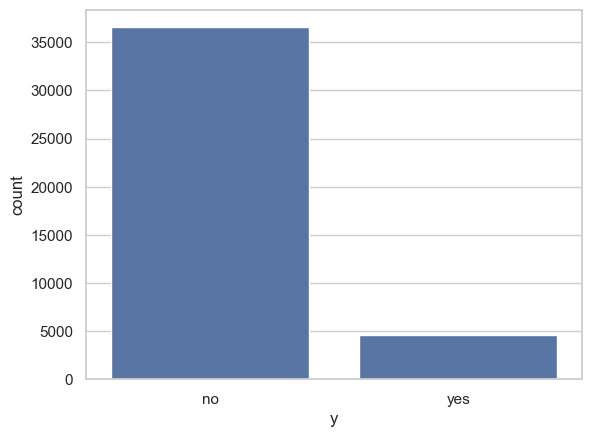

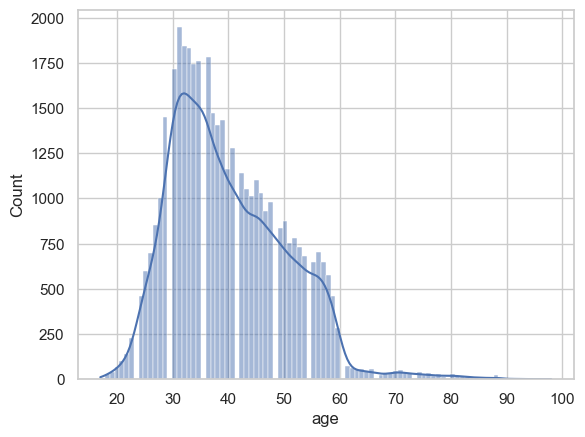

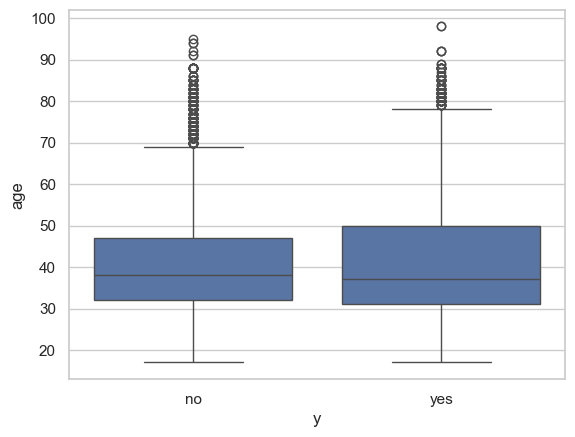

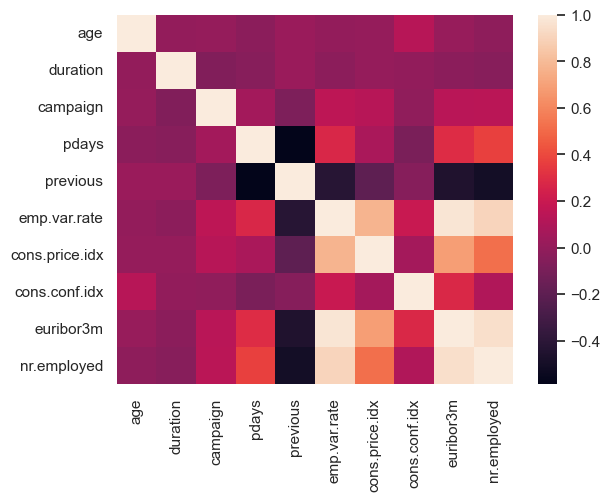

In [78]:
# Exploratory Data Analysis

sns.countplot(x='y', data=df)
plt.show()

sns.histplot(df['age'], kde=True)
plt.show()

sns.boxplot(x='y', y='age', data=df)
plt.show()

sns.heatmap(df.corr(numeric_only=True))
plt.show()

## Exploratory Data Analysis

Key insights:

- Most customers did not subscribe.
- Certain age groups showed higher conversion rates.
- Previous campaign success strongly influenced subscription likelihood.
- Economic indicators impacted customer decisions.

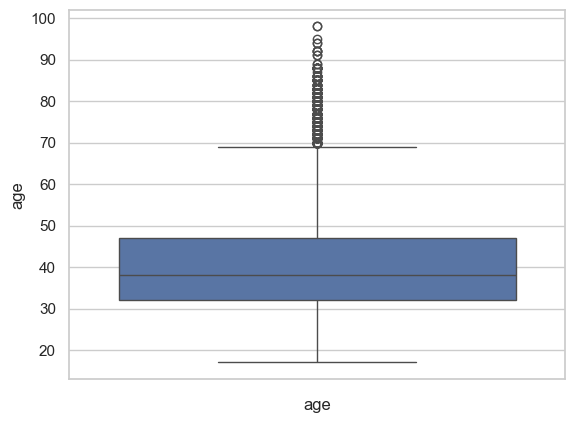

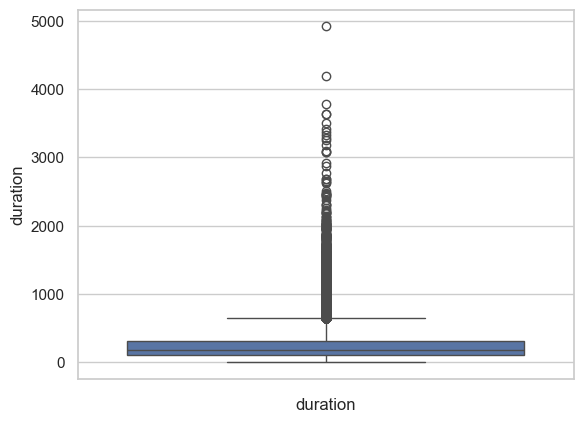

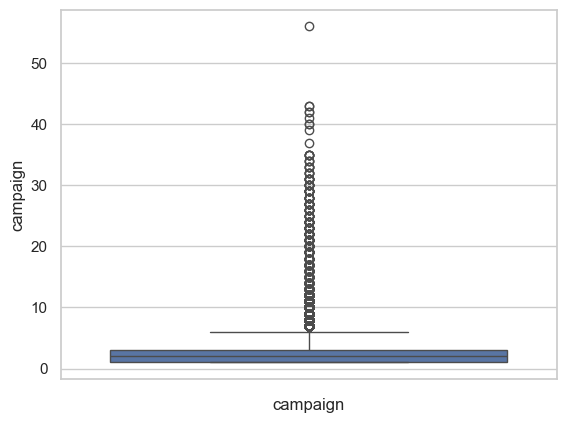

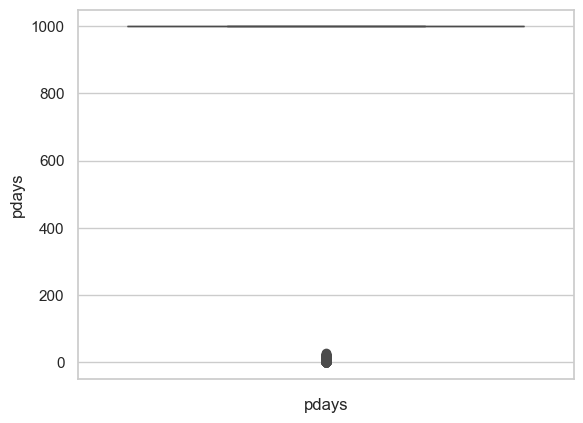

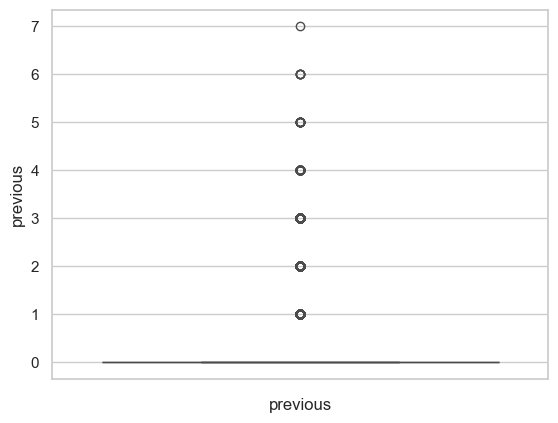

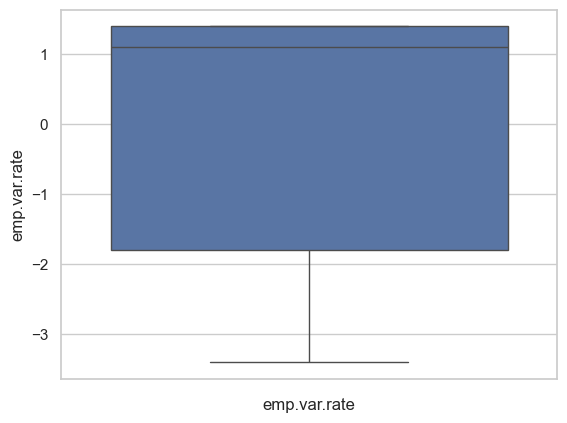

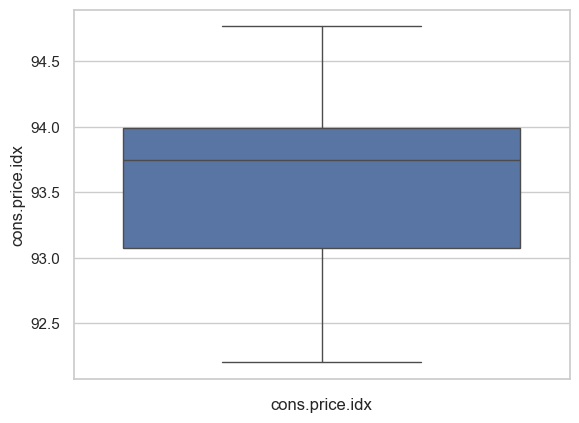

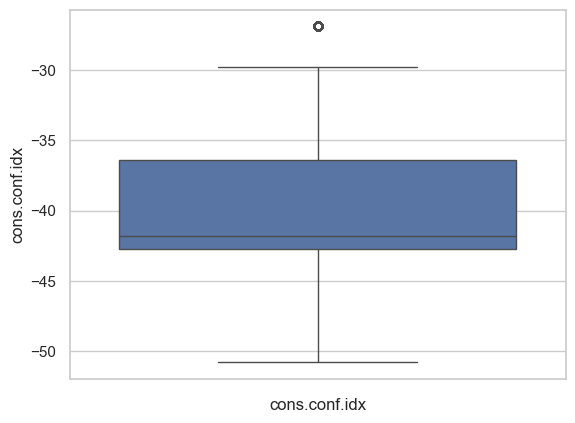

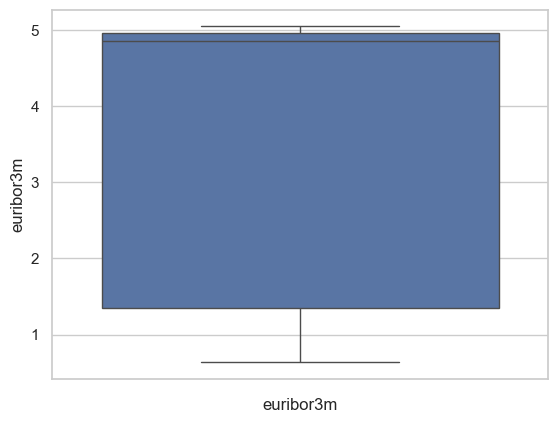

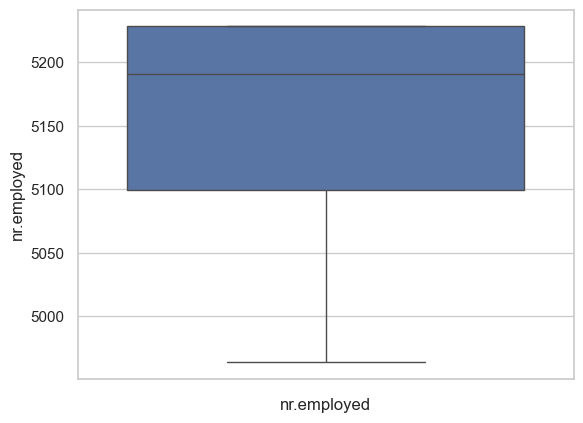

In [79]:
# Outlier Detection

# Boxplot for Numerical Columns
for col in df.columns:
  if df[col].dtype !='object':
    sns.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

In [80]:
# Outlier Handling

col_name = ['age','duration','campaign','cons.price.idx']

for col in col_name:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3-q1

  LB = q1-1.5*iqr
  UB = q3+1.5*iqr

  df = df[(df[col] >= LB) &(df[col] <= UB)]

In [81]:
# Handling Object Data Types

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.columns:
  if df[col].dtype == 'object':
    df[col] = le.fit_transform(df[col])


In [82]:
df.dtypes

age               float64
job                 int32
marital             int32
education           int32
default             int32
housing             int32
loan                int32
contact             int32
month               int32
day_of_week         int32
duration          float64
campaign          float64
pdays             float64
previous          float64
poutcome            int32
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                   int32
dtype: object

In [83]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [84]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [85]:
# Model Building

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [86]:
# Model Evaluation

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9321795412973125
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      6513
           1       0.66      0.38      0.48       594

    accuracy                           0.93      7107
   macro avg       0.81      0.68      0.72      7107
weighted avg       0.92      0.93      0.92      7107



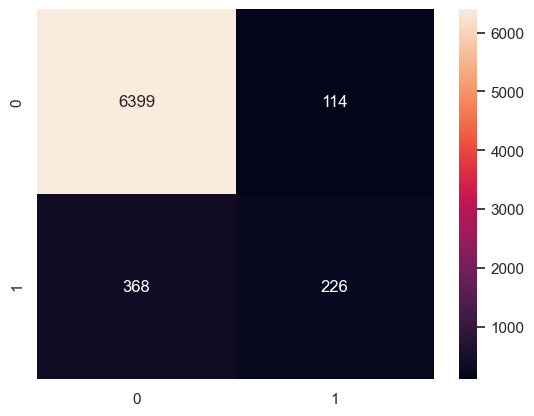

In [87]:
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d'
)
plt.show()

## Business Insights

- Previous campaign outcomes significantly impact customer decisions.
- Customers contacted through specific communication channels show higher conversion rates.
- Targeted marketing can improve campaign ROI and reduce operational costs.